# **Importing Dependencies**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# **Loading dataset**

In [49]:
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')  # We'll use test as validation
val_dir = os.path.join(base_dir, 'val')   # Small validation set

# **Parameters**

In [50]:
img_size = 224  # VGG16 default size
batch_size = 32
epochs = 20

# **Data Augmentation**

In [51]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='constant',
    cval=0,
    brightness_range=[0.9, 1.1],
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [52]:
# Training data
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation data (from training split)
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4434 images belonging to 2 classes.
Found 782 images belonging to 2 classes.


In [53]:
# Test data
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 624 images belonging to 2 classes.


# **VGG16 pre-trained model**

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))

base_model.trainable = False

# Model architecture
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x) 
x = Dropout(0.6)(x) 
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

optimizer = Adam(learning_rate=1e-5)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# **Callbacks**

In [55]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

# **Model Training**

In [56]:
history = model.fit(
    train_gen,
    epochs=epochs,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/20
139/139 [==============================] - 128s 908ms/step - loss: 0.1503 - accuracy: 0.9396 - val_loss: 0.1552 - val_accuracy: 0.9348 - lr: 1.0000e-05
Epoch 2/20
139/139 [==============================] - 122s 877ms/step - loss: 0.1300 - accuracy: 0.9490 - val_loss: 0.1125 - val_accuracy: 0.9552 - lr: 1.0000e-05
Epoch 3/20
139/139 [==============================] - 121s 873ms/step - loss: 0.1109 - accuracy: 0.9562 - val_loss: 0.1087 - val_accuracy: 0.9604 - lr: 1.0000e-05
Epoch 4/20
139/139 [==============================] - 116s 837ms/step - loss: 0.1159 - accuracy: 0.9544 - val_loss: 0.1129 - val_accuracy: 0.9527 - lr: 1.0000e-05
Epoch 5/20
139/139 [==============================] - 121s 870ms/step - loss: 0.1102 - accuracy: 0.9585 - val_loss: 0.1087 - val_accuracy: 0.9514 - lr: 1.0000e-05
Epoch 6/20
139/139 [==============================] - 121s 874ms/step - loss: 0.1048 - accuracy: 0.9637 - val_loss: 0.1133 - val_accuracy: 0.9552 - lr: 1.0000e-05
Epoch 7/20
139/139 [==

# **Evaluate on test set**

In [57]:
print("\nEvaluating on Test Set:")
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.4f}")



Evaluating on Test Set:
20/20 [==============================] - 7s 327ms/step - loss: 0.2360 - accuracy: 0.9247

Test Accuracy: 0.9247


# **Classification Report**

In [58]:
y_true = test_gen.classes
y_pred = (model.predict(test_gen) > 0.5).astype("int32")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

20/20 [==============================] - 7s 297ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.88      0.90       234
   PNEUMONIA       0.93      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624



# **Precision-Recall Curve**


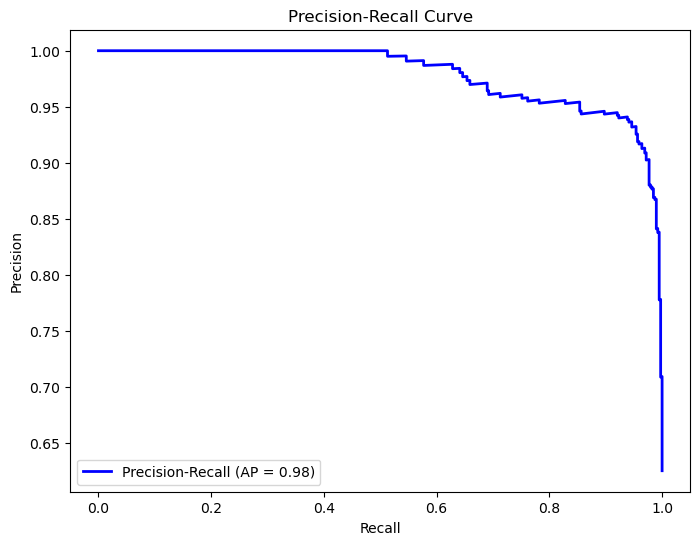

In [63]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(test_gen.classes, y_pred_probs)
avg_precision = average_precision_score(test_gen.classes, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, 
         label=f'Precision-Recall (AP = {avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# **Confusion matrix**

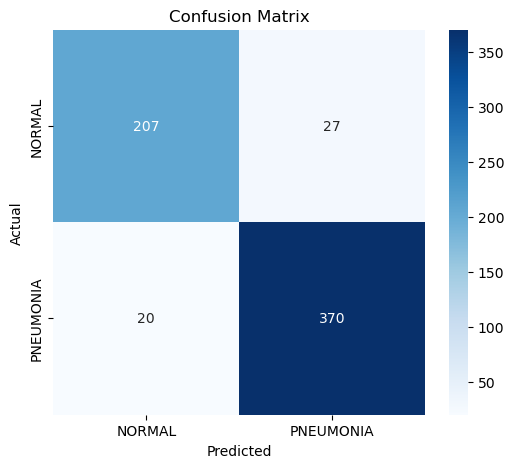

In [59]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NORMAL', 'PNEUMONIA'], 
            yticklabels=['NORMAL', 'PNEUMONIA'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Plot training history**

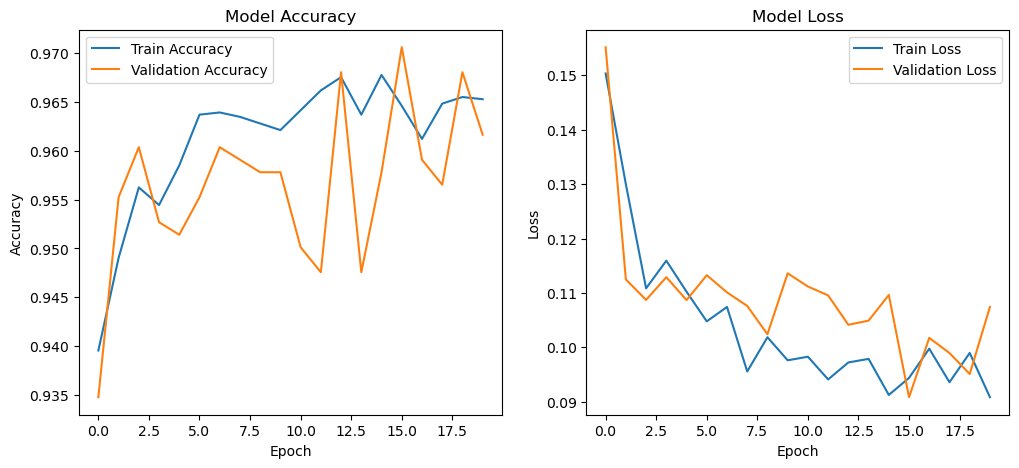

In [60]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# **ROC Curve**

20/20 [==============================] - 6s 297ms/step


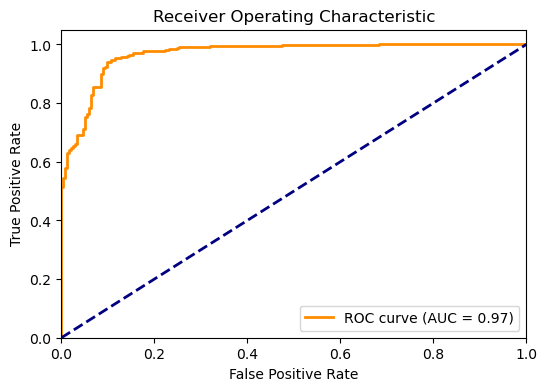

In [62]:
from sklearn.metrics import roc_curve, auc

y_pred_probs = model.predict(test_gen)
fpr, tpr, thresholds = roc_curve(test_gen.classes, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# **Prediction Distribution**

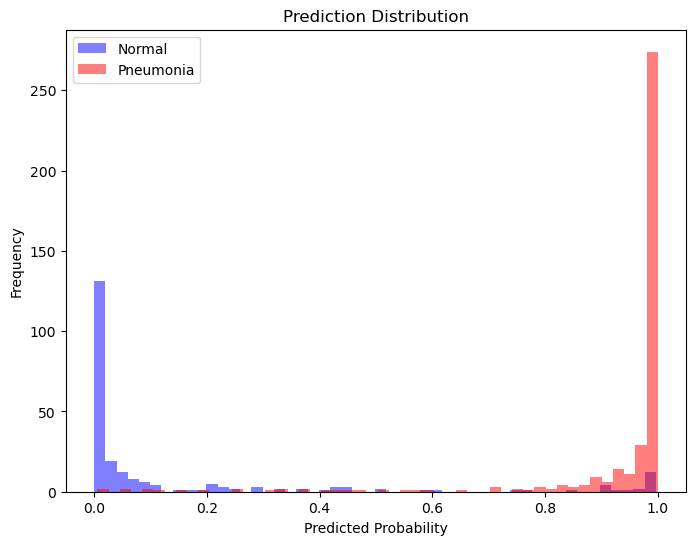

In [64]:
plt.figure(figsize=(8, 6))
plt.hist(y_pred_probs[test_gen.classes == 0], bins=50, alpha=0.5, label='Normal', color='blue')
plt.hist(y_pred_probs[test_gen.classes == 1], bins=50, alpha=0.5, label='Pneumonia', color='red')
plt.title('Prediction Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# **Saving the Model**

In [65]:
model.save('pneumonia_detection.h5')